# 1. Regressão

Nessa aba do notebook, tentaremos criar um modelo preditivo para prever as notas de alunos de matemática com base nos seus dados e informações.

In [147]:
# Bibliotecas utilizadas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Carregando os dados
train = pd.read_csv('regressao/train.csv')
train.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,score
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,no,no,4,3,4,1,1,3,6,5.67
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,yes,no,5,3,3,1,1,3,4,5.33
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,yes,no,4,3,2,2,3,3,10,8.33
3,GP,F,15,U,GT3,T,4,2,health,services,...,yes,yes,3,2,2,1,1,5,2,14.67
4,GP,F,16,U,GT3,T,3,3,other,other,...,no,no,4,3,2,1,2,5,4,8.67


In [148]:
train.info()
train.describe()

<class 'pandas.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 31 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   school      395 non-null    str    
 1   sex         395 non-null    str    
 2   age         395 non-null    int64  
 3   address     395 non-null    str    
 4   famsize     395 non-null    str    
 5   Pstatus     395 non-null    str    
 6   Medu        395 non-null    int64  
 7   Fedu        395 non-null    int64  
 8   Mjob        395 non-null    str    
 9   Fjob        395 non-null    str    
 10  reason      395 non-null    str    
 11  guardian    395 non-null    str    
 12  traveltime  395 non-null    int64  
 13  studytime   395 non-null    int64  
 14  failures    395 non-null    int64  
 15  schoolsup   395 non-null    str    
 16  famsup      395 non-null    str    
 17  paid        395 non-null    str    
 18  activities  395 non-null    str    
 19  nursery     395 non-null    str    
 20 

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,score
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.679139
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.696912
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.330000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.330000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,10.670000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.330000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.330000


## 1.1 EDA.

### Análise da distribuição das notas

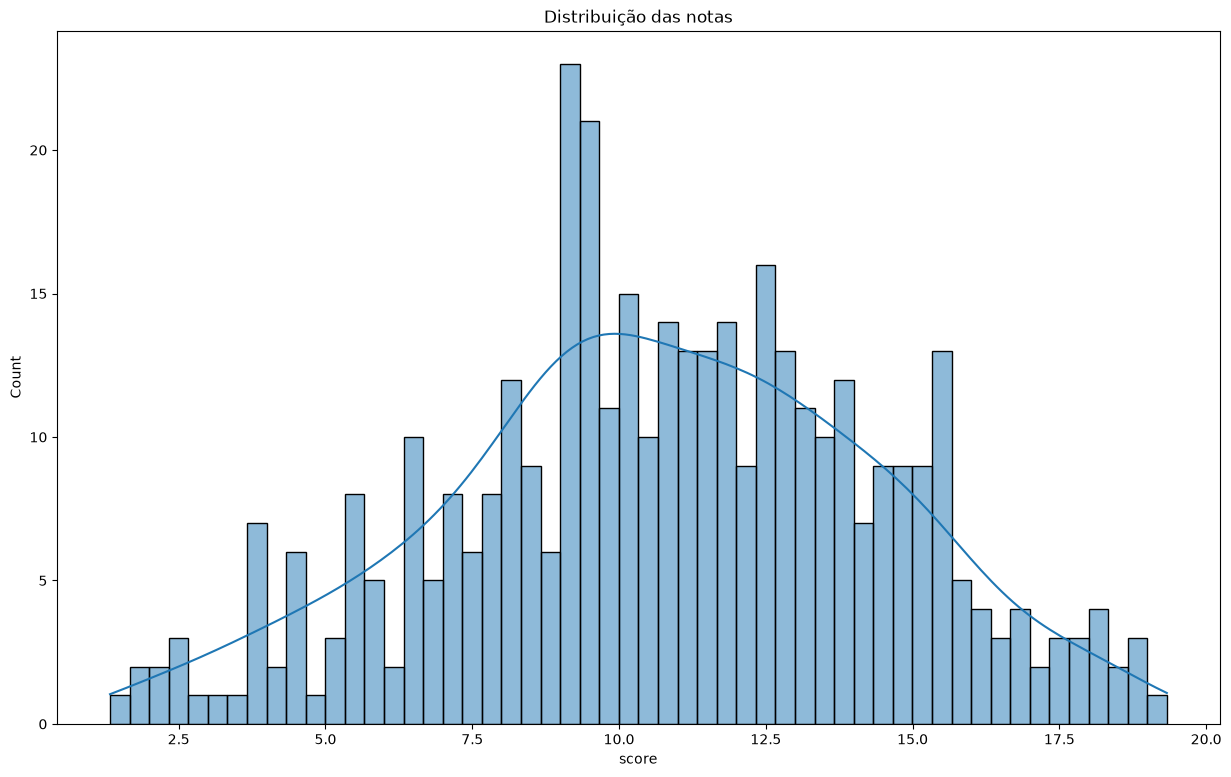

In [149]:
# Visualizando a distribuição das notas, utilizei binwidth = 1/3 porque as notas são "divididas" por 0.33 de distância.
plt.figure(figsize=(15, 9))
sns.histplot(train['score'], binwidth = 1/3, kde=True)
plt.title('Distribuição das notas')
plt.show()


O gráfico mostra todas as notas dos alunos separadas em barras, com essas barras separadas por um intervalo de 0.33. É importante ver isso para analisar se existem casas que podem atrapalhar a análise, como muitos alunos com nota 0 ou uma nota específica com uma quantidade muito diferente de alunos. É importante ver como não existem nenhum outliner extremo, o que vai facilitar na hora de montar o modelo.


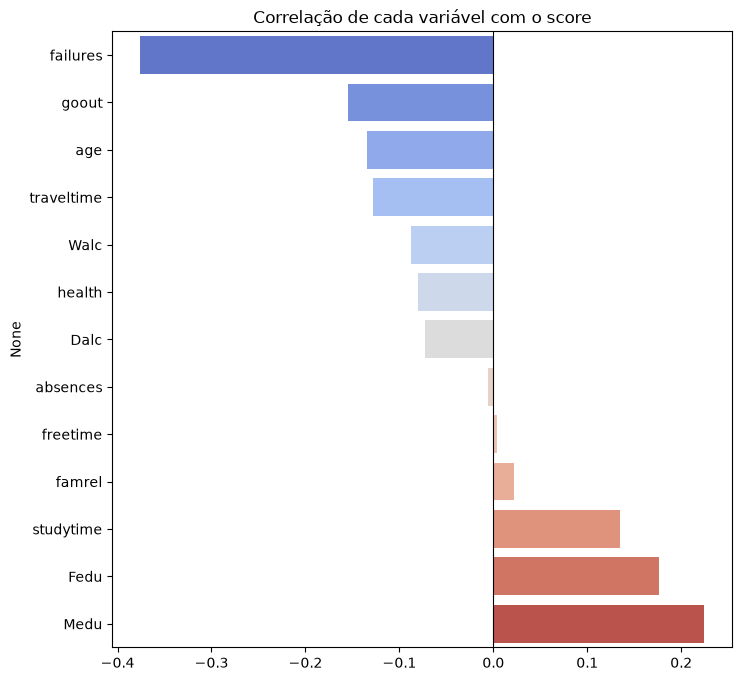

In [150]:
#Analisando a correlação entre as váriaveis numéricas e o score
numeric_cols = train.select_dtypes(include=['int64','float64']).columns
corr = train[numeric_cols].corr()['score'].drop('score').sort_values()

plt.figure(figsize=(8,8))
sns.barplot(x=corr.values, y=corr.index, hue=corr.index, palette='coolwarm', legend=False)
plt.title('Correlação de cada variável com o score')
plt.axvline(0, color='black', linewidth=0.8)
plt.show()



A tabela mostra e correlaciona somente os dados númericos da tabela, descritos no student.txt. Vemos que as correlações positivas mais relevantes são Fedu, Medu e studytime, enquanto as negativas são failures, goout, age e traveltime, com destaque maior para failures, o que sugere que dificuldades relacionadas a matéria tendem a se repetir por vários anos.

### Ensino Superior

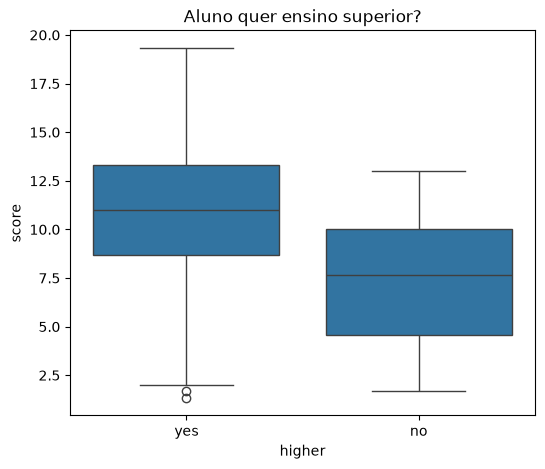

In [151]:
#Analisando a relação entre o aluno querer ensino superior e suas notas.
plt.figure(figsize=(6,5))
sns.boxplot(x='higher', y='score', data=train)
plt.title('Aluno quer ensino superior?')
plt.show()

In [152]:
train['higher'].value_counts()

higher
yes    375
no      20
Name: count, dtype: int64

Aqui vemos que apesar dos alunos que querem ensino superior terem notas mais altas, existem poucos alunos que não querem, então aqui existe uma correlação relevante, apesar da desproporção grande entre yes e no.

### Escola na qual os alunos estudaram

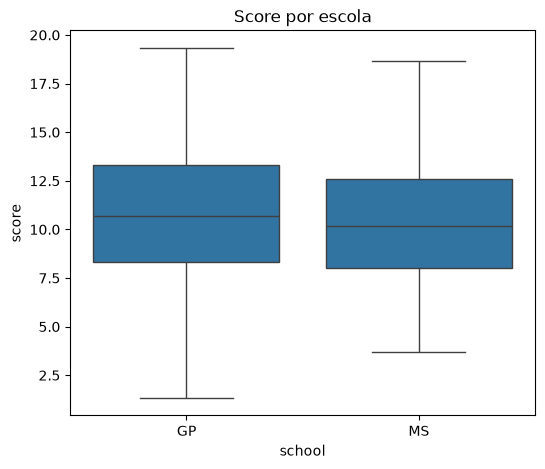

In [153]:
plt.figure(figsize=(6,5))
sns.boxplot(x='school', y='score', data=train)
plt.title('Score por escola')
plt.show()

In [154]:
train['school'].value_counts()

school
GP    349
MS     46
Name: count, dtype: int64

Aqui, apesar dos grupos serem desbalanceados, não há muita diferença entre a mediana das escolas, então provavelmente não há uma correlação muito relevante.

###

### Relacionamentos

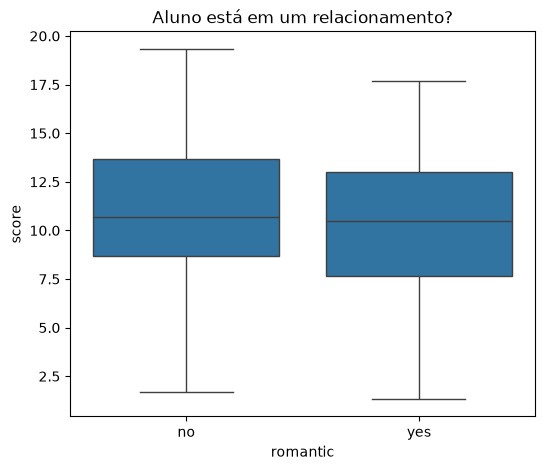

In [155]:
plt.figure(figsize=(6,5))
sns.boxplot(x='romantic', y='score', data=train)
plt.title('Aluno está em um relacionamento?')
plt.show()

In [156]:
train['romantic'].value_counts()

romantic
no     263
yes    132
Name: count, dtype: int64

Aqui, vemos que estar em um relacionamento não afeta de maneira significativa o desempenho escolar.

### Internet

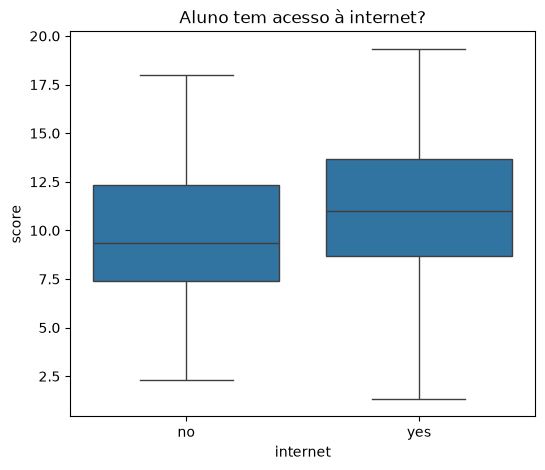

In [157]:
plt.figure(figsize=(6,5))
sns.boxplot(x='internet', y='score', data=train)
plt.title('Aluno tem acesso à internet?')
plt.show()

In [158]:
train['internet'].value_counts()

internet
yes    329
no      66
Name: count, dtype: int64

Aqui, vemos que ter internet não influencia de maneira muito relevante nas notas dos alaunos.

### Apoio educacional extra

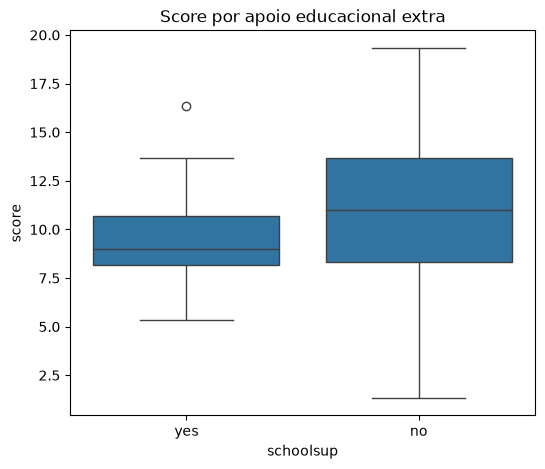

In [159]:
plt.figure(figsize=(6,5))
sns.boxplot(x='schoolsup', y='score', data=train)
plt.title('Score por apoio educacional extra')
plt.show()

In [160]:
train['schoolsup'].value_counts()

schoolsup
no     344
yes     51
Name: count, dtype: int64

Esse dado é curioso, pois é normal imaginar que alunos que tem apoio educacional extra tenham notas mais altas, mas pelo gráfico, parece que quem tem apoio educacional extra, nesse caso, é porque provavelmente tem mais dificuldade na matéria e tem notas mais baixas. Parece existir uma boa correlação aqui, pois tem uma diferença clara entre yes e no.

### Profissão do pai e da mãe

In [161]:
### Trabalho do pai e mãe

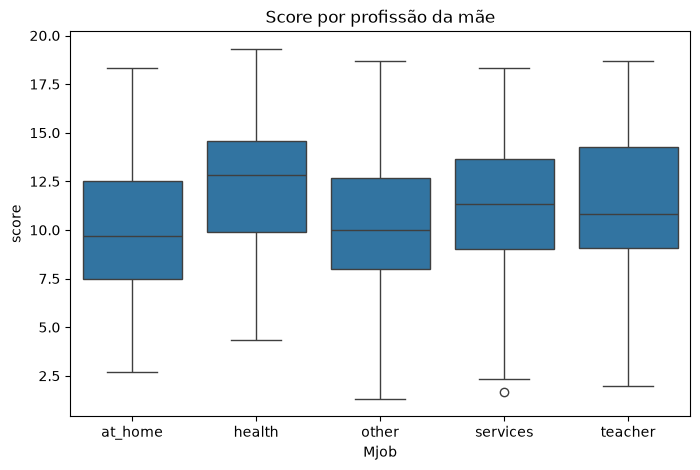

               mean       std  count
Mjob                                
health    12.234706  3.270738     34
teacher   11.269483  3.590234     58
services  11.207087  3.906549    103
other     10.059078  3.527894    141
at_home    9.762542  3.627155     59


In [162]:
# Analisando a relação entre a profissão da mãe e as notas dos alunos.
plt.figure(figsize=(8,5))
sns.boxplot(x='Mjob', y='score', data=train)
plt.title('Score por profissão da mãe')
plt.show()

print(train.groupby('Mjob')['score'].agg(['mean', 'std', 'count']).sort_values('mean', ascending=False))

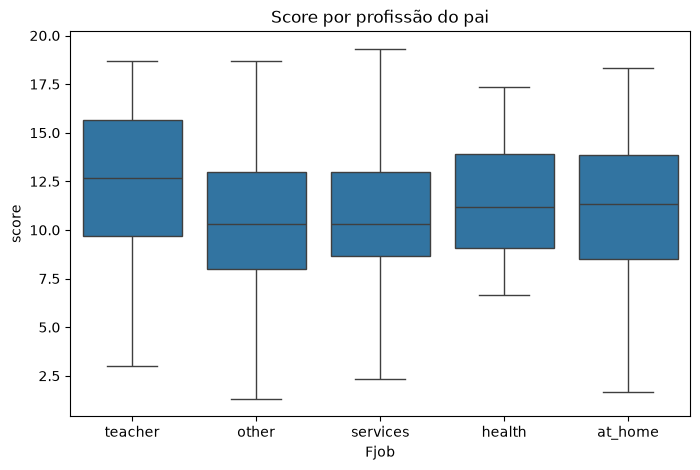

               mean       std  count
Fjob                                
teacher   12.287241  4.636325     29
health    11.482222  2.986276     18
at_home   10.817000  4.388804     20
services  10.669550  3.390542    111
other     10.389816  3.661435    217


In [163]:
# Analisando a relação entre a profissão do pai e as notas dos alunos.
plt.figure(figsize=(8,5))
sns.boxplot(x='Fjob', y='score', data=train)
plt.title('Score por profissão do pai')
plt.show()

print(train.groupby('Fjob')['score'].agg(['mean', 'std', 'count']).sort_values('mean', ascending=False))

Assim, acredito que finalizamos a parte de EDA, olhando para todos os dados que foram julgados relevantes e fazendo uma rápida análise para o que deve ser mais importante.

### Sexo

## 1.2 Limpeza e pré-processamento

Essa aba foi adicionada depois, pois na regressão linear, a coluna sex foi apontada como uma coluna com correlação forte

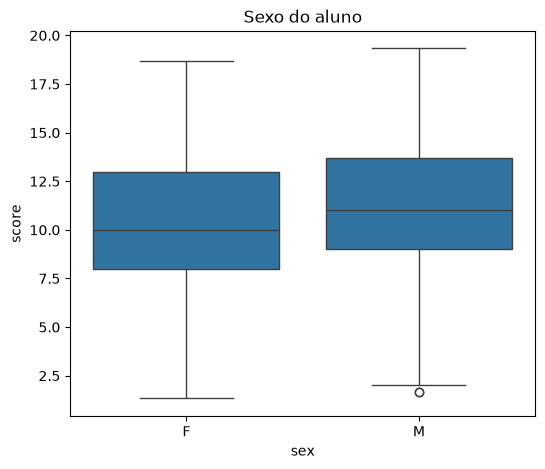

In [164]:
#Analisando o sexo do aluno e suas notas.
plt.figure(figsize=(6,5))
sns.boxplot(x='sex', y='score', data=train)
plt.title('Sexo do aluno')
plt.show()

sex surpreendeu com coeficiente positivo alto, mas a diferença bruta de médias entre grupos é pequena. O motivo: Meninas estudam mais em média (studytime 2.28 vs 1.76), efeito que a regressão linear isolou ao controlar por todas as variáveis ao mesmo tempo, o que aqui, não se mostra da mesma maneira.

In [165]:
# Aplicando a técnica de One-Hot Encoding para as variáveis categóricas
train_encoded = pd.get_dummies(train, columns=['Mjob', 'Fjob', 'reason', 'guardian'], drop_first=True)
train_encoded.head()


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,traveltime,studytime,...,Mjob_teacher,Fjob_health,Fjob_other,Fjob_services,Fjob_teacher,reason_home,reason_other,reason_reputation,guardian_mother,guardian_other
0,GP,F,18,U,GT3,A,4,4,2,2,...,False,False,False,False,True,False,False,False,True,False
1,GP,F,17,U,GT3,T,1,1,1,2,...,False,False,True,False,False,False,False,False,False,False
2,GP,F,15,U,LE3,T,1,1,1,2,...,False,False,True,False,False,False,True,False,True,False
3,GP,F,15,U,GT3,T,4,2,1,3,...,False,False,False,True,False,True,False,False,True,False
4,GP,F,16,U,GT3,T,3,3,1,2,...,False,False,True,False,False,True,False,False,False,False


In [166]:
# Analisando se a quantidade de colunas adicionadas está correta após o get_dummies.
train.shape

(395, 31)

In [167]:
train_encoded.shape

(395, 40)

In [168]:
# Entendendo quais são as variáveis binárias.
binary_cols = ['school', 'sex', 'address', 'famsize', 'Pstatus', 'schoolsup', 
               'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']

for col in binary_cols:
    print(col, train_encoded[col].unique())

school <StringArray>
['GP', 'MS']
Length: 2, dtype: str
sex <StringArray>
['F', 'M']
Length: 2, dtype: str
address <StringArray>
['U', 'R']
Length: 2, dtype: str
famsize <StringArray>
['GT3', 'LE3']
Length: 2, dtype: str
Pstatus <StringArray>
['A', 'T']
Length: 2, dtype: str
schoolsup <StringArray>
['yes', 'no']
Length: 2, dtype: str
famsup <StringArray>
['no', 'yes']
Length: 2, dtype: str
paid <StringArray>
['no', 'yes']
Length: 2, dtype: str
activities <StringArray>
['no', 'yes']
Length: 2, dtype: str
nursery <StringArray>
['yes', 'no']
Length: 2, dtype: str
higher <StringArray>
['yes', 'no']
Length: 2, dtype: str
internet <StringArray>
['no', 'yes']
Length: 2, dtype: str
romantic <StringArray>
['no', 'yes']
Length: 2, dtype: str


In [169]:
mapping = {
    'school':     {'GP': 0, 'MS': 1},
    'sex':        {'F': 0, 'M': 1},
    'address':    {'R': 0, 'U': 1},      # U = urbano = 1
    'famsize':    {'LE3': 0, 'GT3': 1},  # GT3 = família grande = 1
    'Pstatus':    {'A': 0, 'T': 1},      # T = pais juntos = 1
    'schoolsup':  {'no': 0, 'yes': 1},
    'famsup':     {'no': 0, 'yes': 1},
    'paid':       {'no': 0, 'yes': 1},
    'activities': {'no': 0, 'yes': 1},
    'nursery':    {'no': 0, 'yes': 1},
    'higher':     {'no': 0, 'yes': 1},
    'internet':   {'no': 0, 'yes': 1},
    'romantic':   {'no': 0, 'yes': 1},
}

for col, m in mapping.items():
    train_encoded[col] = train_encoded[col].map(m)

train_encoded.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,traveltime,studytime,...,Mjob_teacher,Fjob_health,Fjob_other,Fjob_services,Fjob_teacher,reason_home,reason_other,reason_reputation,guardian_mother,guardian_other
0,0,0,18,1,1,0,4,4,2,2,...,False,False,False,False,True,False,False,False,True,False
1,0,0,17,1,1,1,1,1,1,2,...,False,False,True,False,False,False,False,False,False,False
2,0,0,15,1,0,1,1,1,1,2,...,False,False,True,False,False,False,True,False,True,False
3,0,0,15,1,1,1,4,2,1,3,...,False,False,False,True,False,True,False,False,True,False
4,0,0,16,1,1,1,3,3,1,2,...,False,False,True,False,False,True,False,False,False,False


In [170]:
# Separando as variáveis que o modelo vai usar e o que queremos prever.
X = train_encoded.drop(columns=['score'])
y = train_encoded['score']

print(X.shape)
print(y.shape)

(395, 39)
(395,)


In [171]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_val_scaled = scaler.transform(X_val)

print(X_train.shape, X_val.shape)

(316, 39) (79, 39)


## 1.3 Modelo de infêrencia

### Regressão Linear

In [172]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error

modelo_lr = LinearRegression()
modelo_lr.fit(X_train_scaled, y_train)

pred_val = modelo_lr.predict(X_val_scaled)
rmse_lr = root_mean_squared_error(y_val, pred_val)

print(f"RMSE Regressão Linear (validação): {rmse_lr:.2f}")

RMSE Regressão Linear (validação): 3.37


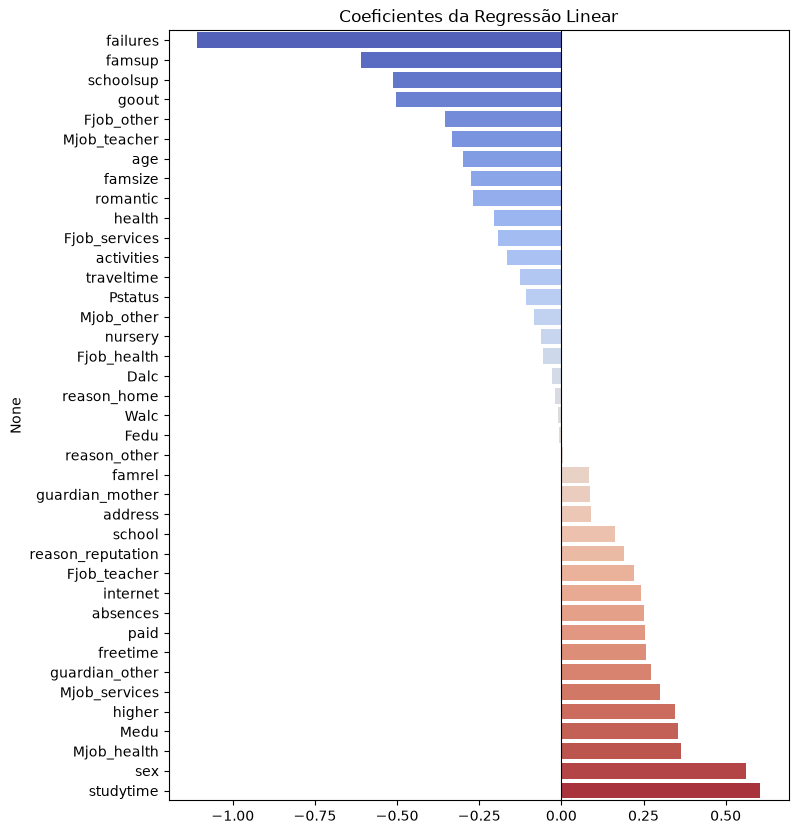

In [173]:
coeficientes = pd.Series(modelo_lr.coef_, index=X.columns).sort_values()

plt.figure(figsize=(8,10))
sns.barplot(x=coeficientes.values, y=coeficientes.index, hue=coeficientes.index, palette='coolwarm', legend=False)
plt.title('Coeficientes da Regressão Linear')
plt.axvline(0, color='black', linewidth=0.8)
plt.show()

Os coeficientes confirmaram o que achamos na EDA. Variáveis como failures e goout como efeitos negativos mais fortes, higher e Mjob_health como positivos. schoolsup aparece negativo, reforçando a hipótese de que os alunos com mais dificuldade são os que tem suporte extra.

### Ridge

In [174]:
from sklearn.linear_model import Ridge

modelo_ridge = Ridge(alpha=1.0)
modelo_ridge.fit(X_train_scaled, y_train)
pred_ridge = modelo_ridge.predict(X_val_scaled)
rmse_ridge = root_mean_squared_error(y_val, pred_ridge)


print(f"RMSE Ridge: {rmse_ridge:.2f}")


RMSE Ridge: 3.37


### Lasso

In [175]:
from sklearn.linear_model import Lasso

modelo_lasso2 = Lasso(alpha=0.1)
modelo_lasso2.fit(X_train_scaled, y_train)
pred_lasso2 = modelo_lasso2.predict(X_val_scaled)
rmse_lasso2 = root_mean_squared_error(y_val, pred_lasso2)

coef_lasso2 = pd.Series(modelo_lasso2.coef_, index=X.columns)
print(f"RMSE Lasso: {rmse_lasso2:.2f}")

RMSE Lasso: 3.37


### KNN

In [176]:
from sklearn.neighbors import KNeighborsRegressor
# 15 vizinhos porque foi o que funcionou melhor nos testes.
modelo_knn = KNeighborsRegressor(n_neighbors=15)
modelo_knn.fit(X_train_scaled, y_train)

pred_knn = modelo_knn.predict(X_val_scaled)
rmse_knn = root_mean_squared_error(y_val, pred_knn)

print(f"RMSE KNN (k=5): {rmse_knn:.2f}")

RMSE KNN (k=5): 3.58


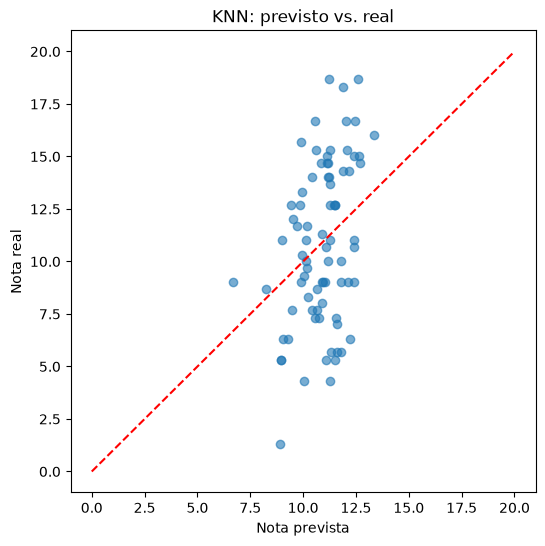

In [177]:
plt.figure(figsize=(6,6))
plt.scatter(pred_knn, y_val, alpha=0.6)
plt.plot([0, 20], [0, 20], color='red', linestyle='--')
plt.xlabel('Nota prevista')
plt.ylabel('Nota real')
plt.title('KNN: previsto vs. real')
plt.show()

In [178]:
from sklearn.svm import SVR

modelo_svr = SVR(kernel='rbf')
modelo_svr.fit(X_train_scaled, y_train)

pred_svr = modelo_svr.predict(X_val_scaled)
rmse_svr = root_mean_squared_error(y_val, pred_svr)

print(f"RMSE SVR (kernel=rbf): {rmse_svr:.2f}")

RMSE SVR (kernel=rbf): 3.50


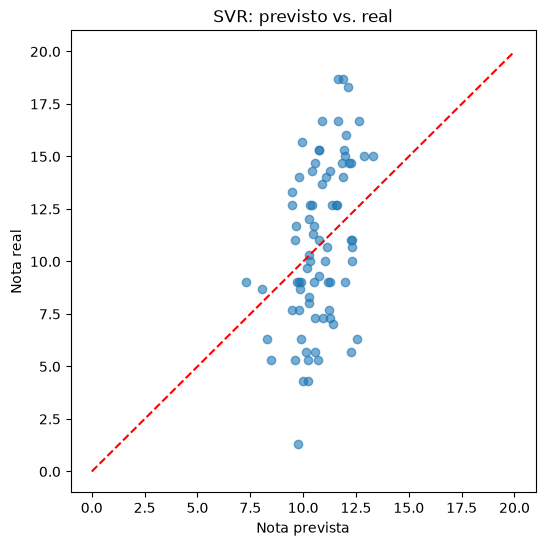

In [179]:
plt.figure(figsize=(6,6))
plt.scatter(pred_svr, y_val, alpha=0.6)
plt.plot([0, 20], [0, 20], color='red', linestyle='--')
plt.xlabel('Nota prevista')
plt.ylabel('Nota real')
plt.title('SVR: previsto vs. real')
plt.show()

### Árvore de Decisão

In [180]:
from sklearn.tree import DecisionTreeRegressor
# 2 porque foi o que funcionou melhor nos testes.
modelo_tree = DecisionTreeRegressor(max_depth=2, random_state=42)
modelo_tree.fit(X_train_scaled, y_train)

pred_tree = modelo_tree.predict(X_val_scaled)
rmse_tree = root_mean_squared_error(y_val, pred_tree)

print(f"RMSE Árvore (max_depth=4): {rmse_tree:.2f}")

RMSE Árvore (max_depth=4): 3.48


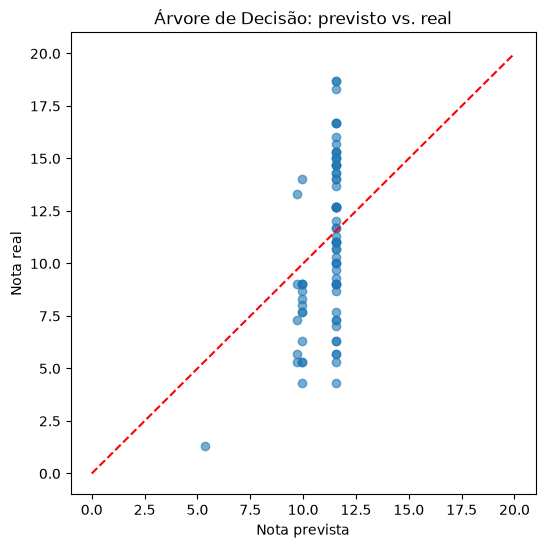

In [181]:
plt.figure(figsize=(6,6))
plt.scatter(pred_tree, y_val, alpha=0.6)
plt.plot([0, 20], [0, 20], color='red', linestyle='--')
plt.xlabel('Nota prevista')
plt.ylabel('Nota real')
plt.title('Árvore de Decisão: previsto vs. real')
plt.show()

### Random Forest

In [182]:
from sklearn.ensemble import RandomForestRegressor

modelo_rf = RandomForestRegressor(n_estimators=200, random_state=42)
modelo_rf.fit(X_train_scaled, y_train)

pred_rf = modelo_rf.predict(X_val_scaled)
rmse_rf = root_mean_squared_error(y_val, pred_rf)

print(f"RMSE Random Forest: {rmse_rf:.2f}")

RMSE Random Forest: 3.31


### Gradient Booster

In [183]:
from sklearn.ensemble import GradientBoostingRegressor

modelo_gb = GradientBoostingRegressor(n_estimators=100, random_state=42)
modelo_gb.fit(X_train_scaled, y_train)

pred_gb = modelo_gb.predict(X_val_scaled)
rmse_gb = root_mean_squared_error(y_val, pred_gb)

print(f"RMSE Gradient Boosting: {rmse_gb:.2f}")

RMSE Gradient Boosting: 3.34


### XGBoost

In [184]:
from xgboost import XGBRegressor

modelo_xgb = XGBRegressor(
    n_estimators=50,
    max_depth=3,
    learning_rate=0.3,
    random_state=42
)
modelo_xgb.fit(X_train_scaled, y_train)

pred_xgb = modelo_xgb.predict(X_val_scaled)
rmse_xgb = root_mean_squared_error(y_val, pred_xgb)

print(f"RMSE XGBoost: {rmse_xgb:.2f}")

RMSE XGBoost: 3.27


### LightGBM

In [185]:
from lightgbm import LGBMRegressor

modelo_lgb = LGBMRegressor(
    n_estimators=50,
    max_depth=8,
    learning_rate=0.1,
    random_state=42,
    verbose=-1
)
modelo_lgb.fit(X_train_scaled, y_train)

pred_lgb = modelo_lgb.predict(X_val_scaled)
rmse_lgb = root_mean_squared_error(y_val, pred_lgb)

print(f"RMSE LightGBM: {rmse_lgb:.2f}")

RMSE LightGBM: 3.19


## 1.4 Criação do submission.csv para o envio

In [186]:

test = pd.read_csv('regressao/test.csv')


test_encoded = pd.get_dummies(test, columns=['Mjob', 'Fjob', 'reason', 'guardian'], drop_first=True)


for col, m in mapping.items():
    test_encoded[col] = test_encoded[col].map(m)


test_encoded = test_encoded.reindex(columns=X.columns, fill_value=0)


scaler_final = StandardScaler()
X_scaled_full = scaler_final.fit_transform(X)
test_scaled = scaler_final.transform(test_encoded)


modelo_final = LGBMRegressor(
    n_estimators=50,
    max_depth=8,
    learning_rate=0.1,
    random_state=42,
    verbose=-1
)
modelo_final.fit(X_scaled_full, y)


pred_test = modelo_final.predict(test_scaled)

submission = pd.DataFrame({
    'id': range(len(test)),
    'score': pred_test.round(2)
})
submission.to_csv('submission.csv', index=False)
submission.head()

,id,score
0,0,13.30
1,1,11.94
2,2,5.41
3,3,11.97
4,4,13.01


# 2. Classificação
Nessa aba do notebook, tentaremos prever se um câncer é benigno ou maligno.

##

In [187]:
train2 = pd.read_csv('classiicacao/train2.csv')
train2.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [188]:
train2.shape

(569, 31)

In [189]:
train2.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    str    
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  569 non-null

In [190]:
train2.describe()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


## 2.1 EDA

### Analisando as proporções da coluna diagnosis

In [191]:
# Quantos tumores são benignos e quantos são malignos
train2["diagnosis"].value_counts()

diagnosis
B    357
M    212
Name: count, dtype: int64

In [192]:
# Porcentagem de tumores benignos x malignos
train2["diagnosis"].value_counts(normalize=True)

diagnosis
B    0.627417
M    0.372583
Name: proportion, dtype: float64

### Procurando valores nulos ou duplicados

In [193]:
train2.isnull().sum()

diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

Não há valores nulos

In [194]:
train2.duplicated().sum()

np.int64(0)

Não há valores duplicados

### Gráfico dos diagnósticos

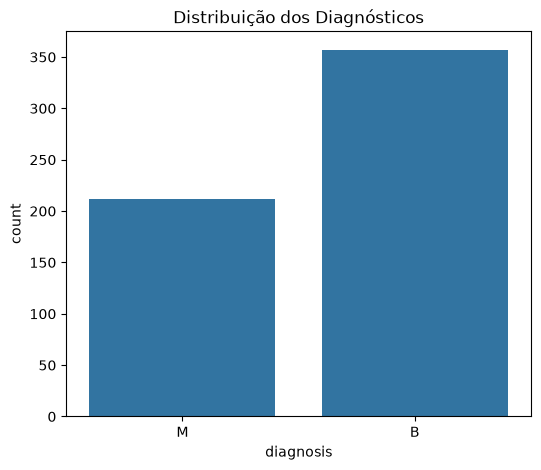

In [195]:
# Analisando a distribuição dos diagnósticos.
plt.figure(figsize=(6,5))
sns.countplot(x='diagnosis', data=train2)
plt.title('Distribuição dos Diagnósticos')
plt.show()

### Média do raio da célula

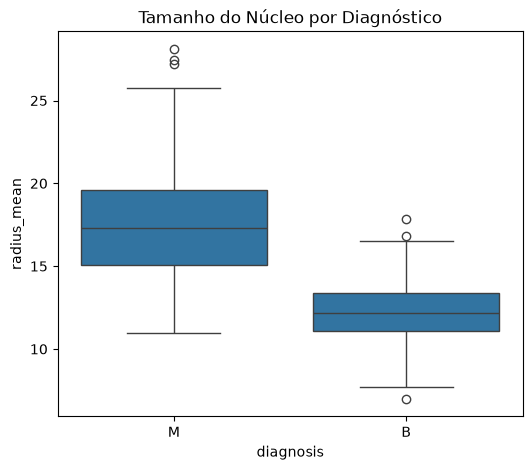

In [196]:
#Analisando a relação entre o tamanho do núcleo e o diagnóstico.
plt.figure(figsize=(6,5))
sns.boxplot(x='diagnosis', y='radius_mean', data=train2)
plt.title('Tamanho do Núcleo por Diagnóstico')
plt.show()

Aqui, vemos claramente que amostras com maior raio médio dos núcleos celulares tendem a estar associadas a diagnósticos malignos.

### Textura da amostra

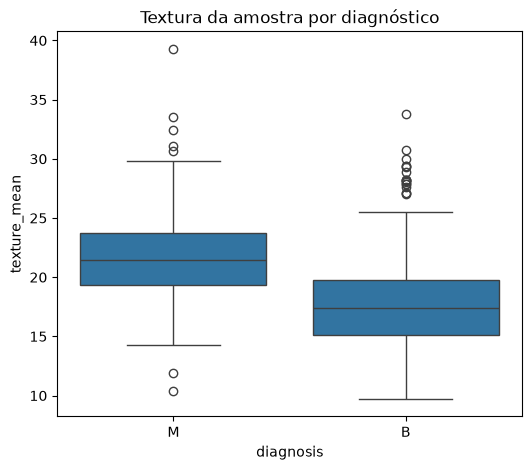

In [197]:
plt.figure(figsize=(6,5))
sns.boxplot(x='diagnosis', y='texture_mean', data=train2)
plt.title('Textura da amostra por diagnóstico')
plt.show()

Aqui, é possível interpretar que quanto mais "texturizada" é a amostra, ela tende a ser uma amostra maligna. Entretanto, existem outliers em ambos os casos, algo que deve ser levado em consideração.

### Suavidade da amostra

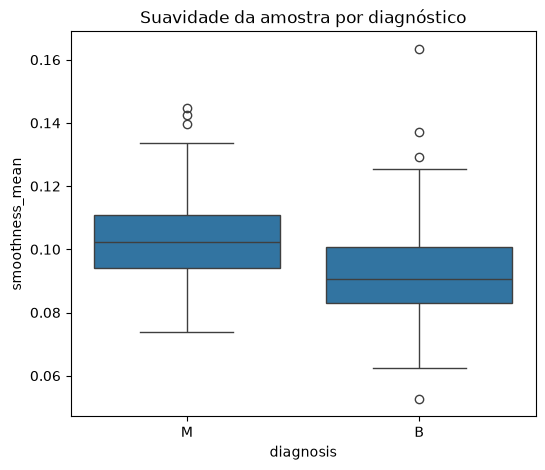

In [198]:
plt.figure(figsize=(6,5))
sns.boxplot(x='diagnosis', y='smoothness_mean', data=train2)
plt.title('Suavidade da amostra por diagnóstico')
plt.show()

A suavidade da amostra não é uma forte indicação de se a amostra é maligna ou não.

## 1.2 Pré-processamento

### Criando e normalizando X e y para treinamento e validação

In [199]:
X = train2.drop("diagnosis", axis=1)
y = train2["diagnosis"]
X.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [200]:
y.head()

0    M
1    M
2    M
3    M
4    M
Name: diagnosis, dtype: str

In [201]:
### Separando treino e validação

X_train2, X_val2, y_train2, y_val2 = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


X_train2.shape

(455, 30)

In [202]:
X_val2.shape


(114, 30)

In [203]:
scaler2 = StandardScaler()
scaler2.fit(X_train2)

X_train_scaled2 = scaler2.transform(X_train2)
X_val_scaled2 = scaler2.transform(X_val2)



## 1.3 Modelo de inferência

### Regressão logística

In [205]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
# Treinamento do modelo
modelo_log = LogisticRegression()
modelo_log.fit(X_train_scaled2, y_train2)


pred_val2 = modelo_log.predict(X_val_scaled2)
acerto_log = accuracy_score(y_val2, pred_val2)


print(f"Taxa de acerto Regressão Logística (validação): {acerto_log:.2%}")

Taxa de acerto Regressão Logística (validação): 96.49%


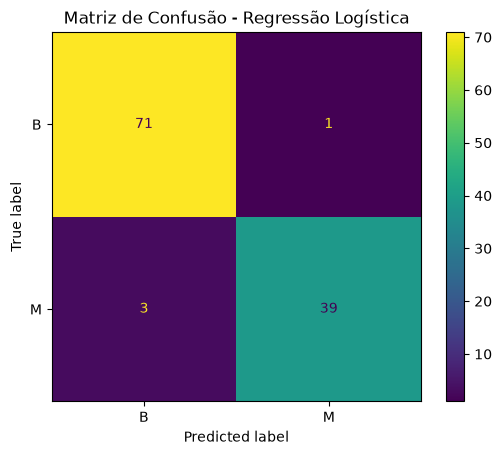

In [206]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
# criação da matriz de confusão
cm_log = confusion_matrix(y_val2, pred_val2)

ConfusionMatrixDisplay(
    confusion_matrix=cm_log,
    display_labels=modelo_log.classes_
).plot()

plt.title("Matriz de Confusão - Regressão Logística")
plt.show()

O modelo de Regressão Logística foi muito bem, acertou 110 de 114 casos, com uma precisão de 96.49%.

### KNN



In [207]:
from sklearn.neighbors import KNeighborsClassifier

modelo_knn = KNeighborsClassifier()
modelo_knn.fit(X_train_scaled2, y_train2)


pred_knn = modelo_knn.predict(X_val_scaled2)
acerto_knn = accuracy_score(y_val2, pred_knn)


print(f"Taxa de acerto KNN (validação): {acerto_knn:.2%}")

Taxa de acerto KNN (validação): 95.61%


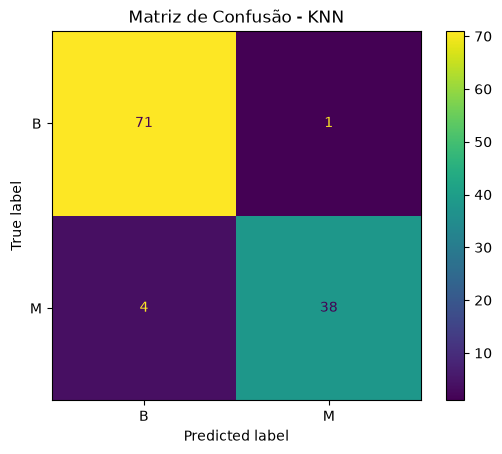

In [208]:
cm_knn = confusion_matrix(y_val2, pred_knn)

ConfusionMatrixDisplay(
    confusion_matrix=cm_knn,
    display_labels=modelo_knn.classes_
).plot()

plt.title("Matriz de Confusão - KNN")
plt.show()

KNN teve um bom desempenho, acertando 109/114 dos casos, com uma precisão de 95.61%.

### Naive Bayes

In [209]:
from sklearn.naive_bayes import GaussianNB

modelo_nb = GaussianNB()
modelo_nb.fit(X_train_scaled2, y_train2)


pred_nb = modelo_nb.predict(X_val_scaled2)
acerto_nb = accuracy_score(y_val2, pred_nb)


print(f"Taxa de acerto Naive Bayes (validação): {acerto_nb:.2%}")

Taxa de acerto Naive Bayes (validação): 92.11%


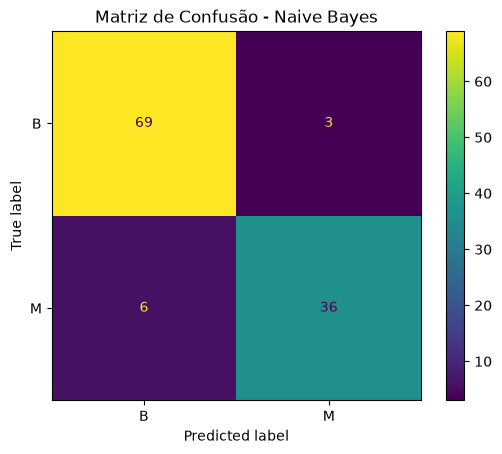

In [210]:
cm_nb = confusion_matrix(y_val2, pred_nb)

ConfusionMatrixDisplay(
    confusion_matrix=cm_nb,
    display_labels=modelo_nb.classes_
).plot()

plt.title("Matriz de Confusão - Naive Bayes")
plt.show()

O Naive Bayes foi um pouco abaixo do resto dos outros modelos, registrando 92.11%, com 105/114 acertos.

### SVM

In [211]:
from sklearn.svm import SVC

modelo_svm = SVC()
modelo_svm.fit(X_train_scaled2, y_train2)


pred_svm = modelo_svm.predict(X_val_scaled2)
acerto_svm = accuracy_score(y_val2, pred_svm)


print(f"Taxa de acerto SVM (validação): {acerto_svm:.2%}")

Taxa de acerto SVM (validação): 97.37%


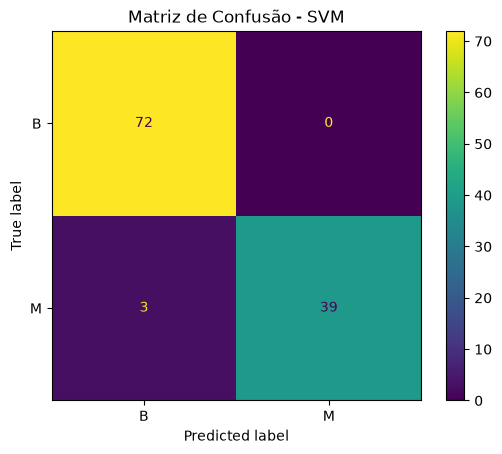

In [212]:
cm_svm = confusion_matrix(y_val2, pred_svm)

ConfusionMatrixDisplay(
    confusion_matrix=cm_svm,
    display_labels=modelo_svm.classes_
).plot()

plt.title("Matriz de Confusão - SVM")
plt.show()

O SVM teve um desempenho excelente, acertou 111 de 114 casos, com uma precisão de 97.37% e 0 falsos positivos.

In [213]:
from sklearn.tree import DecisionTreeClassifier

modelo_arvore = DecisionTreeClassifier(random_state=42)
modelo_arvore.fit(X_train_scaled2, y_train2)


pred_arvore = modelo_arvore.predict(X_val_scaled2)
acerto_arvore = accuracy_score(y_val2, pred_arvore)


print(f"Taxa de acerto Árvore de Decisão (validação): {acerto_arvore:.2%}")

Taxa de acerto Árvore de Decisão (validação): 92.98%


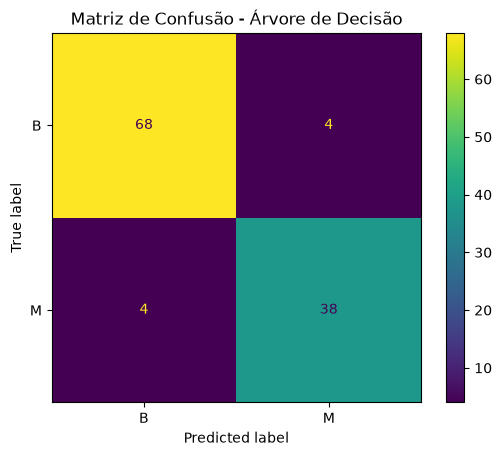

In [216]:
cm_arvore = confusion_matrix(y_val2, pred_arvore)

ConfusionMatrixDisplay(
    confusion_matrix=cm_arvore,
    display_labels=modelo_arvore.classes_
).plot()

plt.title("Matriz de Confusão - Árvore de Decisão")
plt.show()

Como a árvore é um modelo mais instável, os dados escolhidos para o treinamento provavelmente prejudicaram ela, visto que ela teve um desempenho abaixo de quase todos os outros modelos.

### Random Forest

In [217]:
from sklearn.ensemble import RandomForestClassifier

modelo_rf = RandomForestClassifier(random_state=42)
modelo_rf.fit(X_train2, y_train2)


pred_rf = modelo_rf.predict(X_val2)
acerto_rf = accuracy_score(y_val2, pred_rf)


print(f"Taxa de acerto Random Forest (validação): {acerto_rf:.2%}")

Taxa de acerto Random Forest (validação): 97.37%


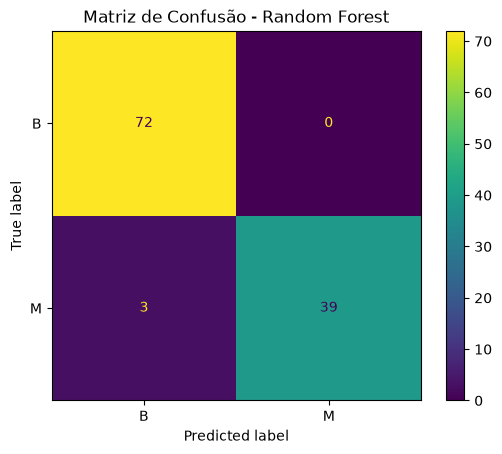

In [218]:
cm_rf = confusion_matrix(y_val2, pred_rf)

ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=modelo_rf.classes_
).plot()

plt.title("Matriz de Confusão - Random Forest")
plt.show()

O RandomForest também teve um desempenho excelente, acertando também 111 de 114 casos, com uma precisão de 97.37% e 0 falsos positivos.

### Gradient boosting

In [219]:
from sklearn.ensemble import GradientBoostingClassifier

modelo_gb = GradientBoostingClassifier(random_state=42)
modelo_gb.fit(X_train2, y_train2)


pred_gb = modelo_gb.predict(X_val2)
acerto_gb = accuracy_score(y_val2, pred_gb)


print(f"Taxa de acerto Gradient Boosting (validação): {acerto_gb:.2%}")

Taxa de acerto Gradient Boosting (validação): 96.49%


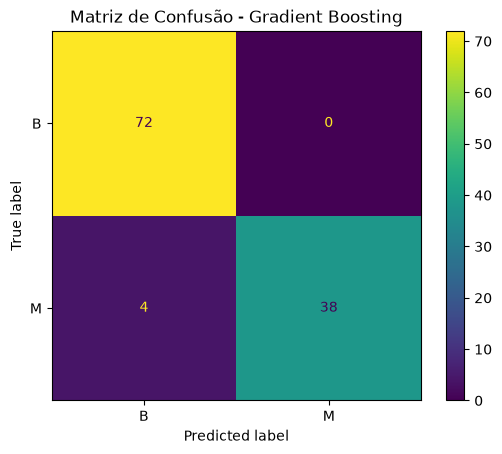

In [220]:
cm_gb = confusion_matrix(y_val2, pred_gb)

ConfusionMatrixDisplay(
    confusion_matrix=cm_gb,
    display_labels=modelo_gb.classes_
).plot()

plt.title("Matriz de Confusão - Gradient Boosting")
plt.show()

O Gradient Boosting foi muito bem também, mas registrou um falso negativo a mais do que os modelos SVM e RandomForest.

### XGBoost

In [221]:
# Transformando diagnosis em números para que o XGBoost trabalhe melhor 
y_train2_num = y_train2.map({"B": 0, "M": 1})
y_val2_num = y_val2.map({"B": 0, "M": 1})

In [222]:
from xgboost import XGBClassifier

modelo_xgb = XGBClassifier(random_state=42)
modelo_xgb.fit(X_train2, y_train2_num)


pred_xgb = modelo_xgb.predict(X_val2)
acerto_xgb = accuracy_score(y_val2_num, pred_xgb)


print(f"Taxa de acerto XGBoost (validação): {acerto_xgb:.2%}")

Taxa de acerto XGBoost (validação): 96.49%


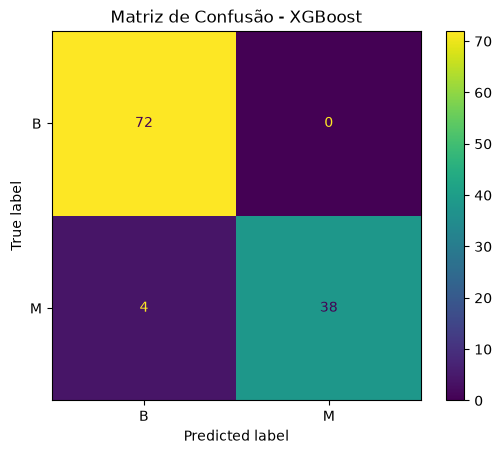

In [223]:
cm_xgb = confusion_matrix(y_val2_num, pred_xgb)

ConfusionMatrixDisplay(
    confusion_matrix=cm_xgb,
    display_labels=["B", "M"]
).plot()

plt.title("Matriz de Confusão - XGBoost")
plt.show()

Teve o resultado exatamente igual ao Gradient Boosting e Regressão Logistica.

## 1.4 Treinamento final e criação do submission2.csv

A escolha final foi pelo SVM, fazendo diversos testes buscando hiperparâmetros ideais, utilizando validações cruzadas e etc. Chegamos nesse números abaixo:

In [242]:
X_final = train2.drop("diagnosis", axis=1)
y_final = train2["diagnosis"]



scaler_final = StandardScaler()
scaler_final.fit(X_final)

X_final_scaled = scaler_final.transform(X_final)


modelo_svm_final = SVC(
    C=6.1477,
    kernel="rbf",
    gamma=0.00533,
    class_weight="balanced"
)


modelo_svm_final.fit(X_final_scaled, y_final);

In [ ]:
# Preparando para criar o submission2.csv
test2 = pd.read_csv("classiicacao/test2.csv")

test2.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,12.645,16.44,74.07,747.7,0.08951,0.05046,0.117298,0.027133,0.1434,0.05830,...,12.828,12.71,87.79,864.2,0.11189,0.10726,0.147406,0.072555,0.2096,0.07857
1,13.292,19.56,80.11,557.4,0.10111,0.15711,0.137410,0.082961,0.1646,0.07370,...,12.519,18.50,84.44,622.9,0.14560,0.40012,0.329984,0.165993,0.2506,0.14659
2,10.725,14.12,53.98,254.4,0.11683,0.11149,0.043338,0.018233,0.1690,0.07969,...,9.929,13.97,71.24,201.1,0.14530,0.32290,0.297290,0.090397,0.2848,0.14177
3,14.202,30.46,98.15,560.3,0.10003,0.11007,0.238674,0.154468,0.1708,0.06092,...,16.473,31.26,84.63,1367.0,0.15024,0.33261,0.745683,0.220761,0.2391,0.08430
4,11.747,19.00,78.87,442.1,0.10517,0.08937,0.039884,0.020402,0.1918,0.06117,...,12.838,23.18,91.74,515.7,0.12267,0.22598,0.057302,0.092982,0.2614,0.08512


In [245]:
test2.shape

(40, 30)

In [248]:
test2_scaled = scaler_final.transform(test2)

pred_test2 = modelo_svm_final.predict(test2_scaled)

print(pred_test2)

['B' 'B' 'B' 'M' 'B' 'M' 'B' 'B' 'B' 'B' 'B' 'B' 'M' 'B' 'B' 'B' 'M' 'M'
 'B' 'B' 'B' 'B' 'M' 'M' 'M' 'B' 'B' 'B' 'B' 'B' 'B' 'B' 'M' 'M' 'B' 'B'
 'M' 'B' 'M' 'B']


In [249]:
submission = pd.DataFrame({
    "id": range(len(pred_test2)),
    "diagnosis": pd.Series(pred_test2).map({
        "B": 0,
        "M": 1
    })
})

submission.to_csv("submission2.csv", index=False)

submission

,id,diagnosis
0,0,0
1,1,0
2,2,0
3,3,1
4,4,0
5,5,1
6,6,0
7,7,0
8,8,0
9,9,0
